## 1. Setup & Imports

In [10]:
import sys
print('Python executable:', sys.executable)
import subprocess
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'lime', 'shap', 'wordcloud', 'transformers', 'datasets',
    'torch', 'scikit-learn', 'pandas', 'numpy', 'seaborn',
    'matplotlib', 'nltk'
])

Python executable: c:\MY SEMESTER PROJECTS\fifa-predictor\.venv\Scripts\python.exe


0

In [11]:
import sys
print('Upgrading pip in notebook kernel:', sys.executable)
import subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip'])

Upgrading pip in notebook kernel: c:\MY SEMESTER PROJECTS\fifa-predictor\.venv\Scripts\python.exe


0

In [12]:
# Core
import os
import re
import sys
import json
import string
import zipfile
import pickle
import random
import warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

# NLP
import nltk
for pkg in ['stopwords', 'punkt', 'punkt_tab']:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass
from nltk.corpus import stopwords

# Classical ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# Deep learning 
try:
    import torch
    from datasets import Dataset
    from transformers import (
        AutoTokenizer, AutoModelForSequenceClassification,
        TrainingArguments, Trainer, pipeline
    )
    HAS_TRANSFORMERS = True
except Exception as _e:
    print('transformers/torch not available - transformer cells will be skipped:', _e)
    HAS_TRANSFORMERS = False

# Explainability
try:
    import lime
    from lime.lime_text import LimeTextExplainer
    HAS_LIME = True
except Exception:
    HAS_LIME = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print('Environment ready. Has transformers:', HAS_TRANSFORMERS, ' Has LIME:', HAS_LIME)


Environment ready. Has transformers: True  Has LIME: True


In [13]:
!pip install -q torch torchvision torchaudio

In [14]:
# ============================================================
# TPU SETUP 
# ============================================================

!pip install -q transformers datasets accelerate sentencepiece

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PJRT_DEVICE"] = "TPU"

from accelerate import Accelerator

accelerator = Accelerator()
device = accelerator.device

print("=" * 50)
print("Device ready:", device)
print("Num processes:", accelerator.num_processes)
print("=" * 50)

TPU_AVAILABLE = "xla" in str(device)

Device ready: cpu
Num processes: 1


In [15]:
# ---------------------------------------------------------------
# Path resolution
# ---------------------------------------------------------------
def find_first(paths):
    for p in paths:
        if Path(p).exists():
            return Path(p)
    return None

FAKE_CSV = find_first([
    'Fake.csv',
    '/content/Fake.csv',
    '/content/project/data/english/Fake.csv',
    'data/Fake.csv',
])
TRUE_CSV = find_first([
    'True.csv',
    '/content/True.csv',
    '/content/project/data/english/True.csv',
    'data/True.csv',
])
URDU_ROOT = find_first([
    'augmented_Urdu_Fake_News_Dataset/augmented_dataset/1.Corpus',
    '/content/augmented_Urdu_Fake_News_Dataset/augmented_dataset/1.Corpus',
    'augmented_dataset/1.Corpus',
])
URDU_ZIP = find_first([
    'augmented_Urdu_Fake_News_Dataset.zip',
    '/content/augmented_Urdu_Fake_News_Dataset.zip',
    '/content/project/data/urdu/augmented_Urdu_Fake_News_Dataset.zip',
])

print('FAKE_CSV :', FAKE_CSV)
print('TRUE_CSV :', TRUE_CSV)
print('URDU_ROOT:', URDU_ROOT)
print('URDU_ZIP :', URDU_ZIP)

for d in ['models', 'outputs']:
    os.makedirs(d, exist_ok=True)


FAKE_CSV : Fake.csv
TRUE_CSV : True.csv
URDU_ROOT: None
URDU_ZIP : augmented_Urdu_Fake_News_Dataset.zip


## 2. Data Loading
We load the full English Reuters fake/real corpus and the Urdu fake-news corpus.

In [16]:
# -----------------------------------------------------------
# ENGLISH - load Fake.csv + True.csv
# -----------------------------------------------------------
english_data_found = FAKE_CSV is not None and TRUE_CSV is not None
if not english_data_found:
    print('Warning: English CSVs not found. Skipping English pipeline.')
    fake_df = pd.DataFrame(columns=['text','subject','date','label'])
    true_df = pd.DataFrame(columns=['text','subject','date','label'])
    english_df = pd.DataFrame(columns=['text','subject','date','label'])
    train_df = pd.DataFrame(columns=['text','subject','date','label','content'])
    test_df = pd.DataFrame(columns=['text','subject','date','label','content'])
else:
    fake_df = pd.read_csv(FAKE_CSV, on_bad_lines='skip', engine='python')
    true_df = pd.read_csv(TRUE_CSV, on_bad_lines='skip', engine='python')
    # Label assignment (0 = Fake, 1 = Real) - applied ONCE here.
    fake_df['label'] = 0
    true_df['label'] = 1
    print('Columns         :', list(fake_df.columns))
    print('Fake.csv shape  :', fake_df.shape)
    print('True.csv shape  :', true_df.shape)
    print()
    print('Subjects in Fake:', dict(fake_df['subject'].value_counts()))
    print('Subjects in True:', dict(true_df['subject'].value_counts()))
    print()
    print('Sample fake article:')
    print(fake_df['text'].iloc[0][:300], '...')


Columns         : ['title', 'text', 'subject', 'date', 'label']
Fake.csv shape  : (23481, 5)
True.csv shape  : (21417, 5)

Subjects in Fake: {'News': np.int64(9050), 'politics': np.int64(6841), 'left-news': np.int64(4459), 'Government News': np.int64(1570), 'US_News': np.int64(783), 'Middle-east': np.int64(778)}
Subjects in True: {'politicsNews': np.int64(11272), 'worldnews': np.int64(10145)}

Sample fake article:
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger a ...


In [17]:
# Keep useful columns. Title is concatenated to text for a richer signal.
for df in (fake_df, true_df):
    df['title'] = df['title'].fillna('').astype(str)
    df['text']  = df['text'].fillna('').astype(str)
    df['text']  = df['title'] + '. ' + df['text']

english_df = pd.concat([fake_df, true_df], ignore_index=True)
english_df = english_df[['text', 'subject', 'date', 'label']]
english_df = english_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print('Combined English shape:', english_df.shape)
print('Label distribution    :', dict(english_df['label'].value_counts()))


Combined English shape: (44898, 4)
Label distribution    : {0: np.int64(23481), 1: np.int64(21417)}


In [18]:
# -----------------------------------------------------------
# URDU - load either from extracted folder OR the zip file.
# -----------------------------------------------------------
def load_urdu_from_dir(root):
    root = Path(root)
    out = {}
    for split in ['Train', 'Test']:
        for cls in ['Fake', 'Real']:
            folder = root / split / cls
            texts = []
            if folder.exists():
                for fp in sorted(folder.glob('*.txt')):
                    try:
                        t = fp.read_text(encoding='utf-8', errors='ignore').strip()
                        if t:
                            texts.append(t)
                    except Exception:
                        pass
            out[(split, cls)] = texts
    return out

def load_urdu_from_zip(zip_path):
    out = {('Train','Fake'): [], ('Train','Real'): [],
           ('Test','Fake'): [],  ('Test','Real'): []}
    with zipfile.ZipFile(zip_path, 'r') as z:
        for name in z.namelist():
            if not name.endswith('.txt'):
                continue
            for split in ['Train', 'Test']:
                for cls in ['Fake', 'Real']:
                    needle = f'1.Corpus/{split}/{cls}/'
                    if needle in name:
                        with z.open(name) as f:
                            t = f.read().decode('utf-8', errors='ignore').strip()
                            if t:
                                out[(split, cls)].append(t)
    return out

if URDU_ROOT is not None:
    urdu_raw = load_urdu_from_dir(URDU_ROOT)
    source = f'directory {URDU_ROOT}'
elif URDU_ZIP is not None:
    urdu_raw = load_urdu_from_zip(URDU_ZIP)
    source = f'zip {URDU_ZIP}'
else:
    raise FileNotFoundError('No Urdu data source found (neither folder nor zip).')

print('Loaded Urdu from:', source)
for k, v in urdu_raw.items():
    print(f'  {k}: {len(v)} docs')

urdu_train_df = pd.DataFrame(
    [(t, 0) for t in urdu_raw[('Train','Fake')]] +
    [(t, 1) for t in urdu_raw[('Train','Real')]],
    columns=['text', 'label']
)
urdu_test_df = pd.DataFrame(
    [(t, 0) for t in urdu_raw[('Test','Fake')]] +
    [(t, 1) for t in urdu_raw[('Test','Real')]],
    columns=['text', 'label']
)
urdu_train_df = urdu_train_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
urdu_test_df  = urdu_test_df .sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print('Urdu train shape:', urdu_train_df.shape)
print('Urdu test  shape:', urdu_test_df.shape)


Loaded Urdu from: zip augmented_Urdu_Fake_News_Dataset.zip
  ('Train', 'Fake'): 1663 docs
  ('Train', 'Real'): 2020 docs
  ('Test', 'Fake'): 646 docs
  ('Test', 'Real'): 865 docs
Urdu train shape: (3683, 2)
Urdu test  shape: (1511, 2)


## 3. Cleaning - drop NA and duplicates
We deduplicate by article text so a near-identical article doesn't leak between train and test.

In [19]:
# -----------------------------------------------------------
# ENGLISH - drop nulls, duplicates, very short docs.
# We split AFTER dedup so duplicates can't leak across train/test.
# -----------------------------------------------------------
before = len(english_df)
english_df = english_df.dropna(subset=['text'])
english_df = english_df[english_df['text'].str.strip().str.len() > 20]
english_df = english_df.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f'English after cleaning: {len(english_df)} (was {before})')
print('Label distribution:', dict(english_df['label'].value_counts()))

# Stratified train/test split on FULL data (was previously capped at ~3.7k rows).
train_df, test_df = train_test_split(
    english_df,
    test_size=0.2,
    stratify=english_df['label'],
    random_state=RANDOM_STATE,
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f'Train: {len(train_df)}   Test: {len(test_df)}')


English after cleaning: 39105 (was 44898)
Label distribution: {1: np.int64(21197), 0: np.int64(17908)}
Train: 31284   Test: 7821


In [20]:
# -----------------------------------------------------------
# URDU - drop nulls / duplicates within each split.
# -----------------------------------------------------------
for name, df in [('urdu_train_df', urdu_train_df), ('urdu_test_df', urdu_test_df)]:
    before = len(df)
    df.dropna(subset=['text'], inplace=True)
    df.drop_duplicates(subset=['text'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'{name}: {len(df)} (was {before})')

# Drop train rows that also appear in test - prevents leakage.
leak = set(urdu_test_df['text']) & set(urdu_train_df['text'])
if leak:
    urdu_train_df = urdu_train_df[~urdu_train_df['text'].isin(leak)].reset_index(drop=True)
    print(f'Removed {len(leak)} leaked rows from urdu_train_df')


urdu_train_df: 3606 (was 3683)
urdu_test_df: 1502 (was 1511)
Removed 39 leaked rows from urdu_train_df


## 4. Text Preprocessing
Both languages get their own cleaner. The cleaned text lives in `content` and is what we feed to the vectorizer.

In [22]:
# -----------------------------------------------------------
# ENGLISH cleaner
# -----------------------------------------------------------
ENGLISH_STOPWORDS = set(stopwords.words('english'))

_URL_RE   = re.compile(r'http\S+|www\S+')
_HTML_RE  = re.compile(r'<.*?>')
_NUM_RE   = re.compile(r'\d+')
_SPACE_RE = re.compile(r'\s+')
_PUNCT_TABLE = str.maketrans('', '', string.punctuation)

def clean_english_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = _URL_RE.sub(' ', text)
    text = _HTML_RE.sub(' ', text)
    text = text.translate(_PUNCT_TABLE)
    text = _NUM_RE.sub(' ', text)
    text = _SPACE_RE.sub(' ', text).strip()
    words = [w for w in text.split() if w not in ENGLISH_STOPWORDS and len(w) > 1]
    return ' '.join(words)

train_df['content'] = train_df['text'].apply(clean_english_text)
test_df ['content'] = test_df ['text'].apply(clean_english_text)


train_df = train_df[train_df['content'].str.len() > 0].reset_index(drop=True)
test_df  = test_df [test_df ['content'].str.len() > 0].reset_index(drop=True)
print('English cleaning done.  Train:', len(train_df), '  Test:', len(test_df))
print('Sample cleaned:', train_df['content'].iloc[0][:200])


English cleaning done.  Train: 31281   Test: 7819
Sample cleaned: another clinton casualty activist murdered openly blaming hillary meddling role honduran coup video far left publications like democracy global research start questioning hillary involvement murder ho


In [23]:
# -----------------------------------------------------------
# URDU cleaner
# -----------------------------------------------------------
URDU_STOPWORDS = set([
    'اور','کے','کی','کا','میں','ہے','ہیں','کو','نے','سے',
    'پر','یہ','وہ','ان','اس','جو','بھی','ہو','تھا','تھی',
    'تھے','گا','گی','گے','لیے','تک','لئے','ہی','جب','تو',
    'اگر','مگر','لیکن','یا','نہیں','نہ','کہ','جس','اب',
    'پھر','کیا','ایک','ہر','سب','ہم','آپ','ساتھ','رہا',
    'رہی','رہے','دیا','دی','ہوا','ہوئی','ہوئے','کر','کرنا',
    'کرتا','کرتی','کرتے','ہوتا','ہوتی','ہوتے',
])

_URDU_PUNCT_RE = re.compile(r'[،؟؛۔٪!"#$%&\'()*+,\-./:;<=>?@\[\]^_`{|}~]')
_DIACRITIC_RE  = re.compile(r'[\u064B-\u065F]')
_DIGIT_RE      = re.compile(r'[0-9\u06F0-\u06F9\u0660-\u0669]')
_LATIN_RE      = re.compile(r'[A-Za-z]')

def clean_urdu_text(text):
    if not isinstance(text, str):
        return ''
    # Normalise Arabic letters to Urdu equivalents
    text = (text
        .replace('ي', 'ی').replace('ك', 'ک').replace('ة', 'ہ')
        .replace('أ', 'ا').replace('إ', 'ا').replace('آ', 'ا'))
    text = _URL_RE.sub(' ', text)
    text = _DIACRITIC_RE.sub('', text)
    text = _URDU_PUNCT_RE.sub(' ', text)
    text = _DIGIT_RE.sub(' ', text)
    text = _LATIN_RE.sub(' ', text)
    text = _SPACE_RE.sub(' ', text).strip()
    words = [w for w in text.split() if w not in URDU_STOPWORDS and len(w) > 1]
    return ' '.join(words)

urdu_train_df['content'] = urdu_train_df['text'].apply(clean_urdu_text)
urdu_test_df ['content'] = urdu_test_df ['text'].apply(clean_urdu_text)

urdu_train_df = urdu_train_df[urdu_train_df['content'].str.len() > 0].reset_index(drop=True)
urdu_test_df  = urdu_test_df [urdu_test_df ['content'].str.len() > 0].reset_index(drop=True)
print('Urdu cleaning done.  Train:', len(urdu_train_df), '  Test:', len(urdu_test_df))
print('Sample cleaned:', urdu_train_df['content'].iloc[0][:200])


Urdu cleaning done.  Train: 3567   Test: 1502
Sample cleaned: لائن میڈیا رپورٹس مطابق ممبئی شوبزڈیسک بالی وڈ اداکار امیتابھ بچن شاہ رخ خان فلم بدلہ نظر ائیں بھارتی ذرائع ابلاغ مطابق دونوں اداکار فلمسا سجو ئے گھو تھریلر فلم بدلہ کئی قسم افواہیں چل تھیں جوڑے افواہ


## 5. Feature Engineering
Length / punctuation counts often differ between fake and real articles.

In [24]:
# -----------------------------------------------------------
# ENGLISH features
# -----------------------------------------------------------
for df in (train_df, test_df):
    df['word_count']        = df['content'].apply(lambda x: len(x.split()))
    df['char_count']        = df['text'].apply(len)
    df['exclamation_count'] = df['text'].apply(lambda x: x.count('!'))
    df['question_count']    = df['text'].apply(lambda x: x.count('?'))
    df['uppercase_ratio']   = df['text'].apply(
        lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))

# -----------------------------------------------------------
# URDU features
# -----------------------------------------------------------
for df in (urdu_train_df, urdu_test_df):
    df['word_count']        = df['content'].apply(lambda x: len(x.split()))
    df['char_count']        = df['text'].apply(len)
    df['exclamation_count'] = df['text'].apply(lambda x: x.count('!'))
    df['question_count']    = df['text'].apply(lambda x: x.count('؟') + x.count('?'))

print('Feature engineering done.')
print(train_df[['word_count','char_count','exclamation_count','question_count']].describe().round(2))


Feature engineering done.
       word_count  char_count  exclamation_count  question_count
count    31281.00    31281.00           31281.00        31281.00
mean       235.61     2510.48               0.43            0.64
std        179.97     1952.58               1.47            1.70
min          3.00       32.00               0.00            0.00
25%        127.00     1343.00               0.00            0.00
50%        214.00     2292.00               0.00            0.00
75%        294.00     3167.00               0.00            1.00
max       4850.00    51894.00             133.00           86.00


## 6. Exploratory Data Analysis
Class balance, length distributions, subject mix, and language-specific patterns.

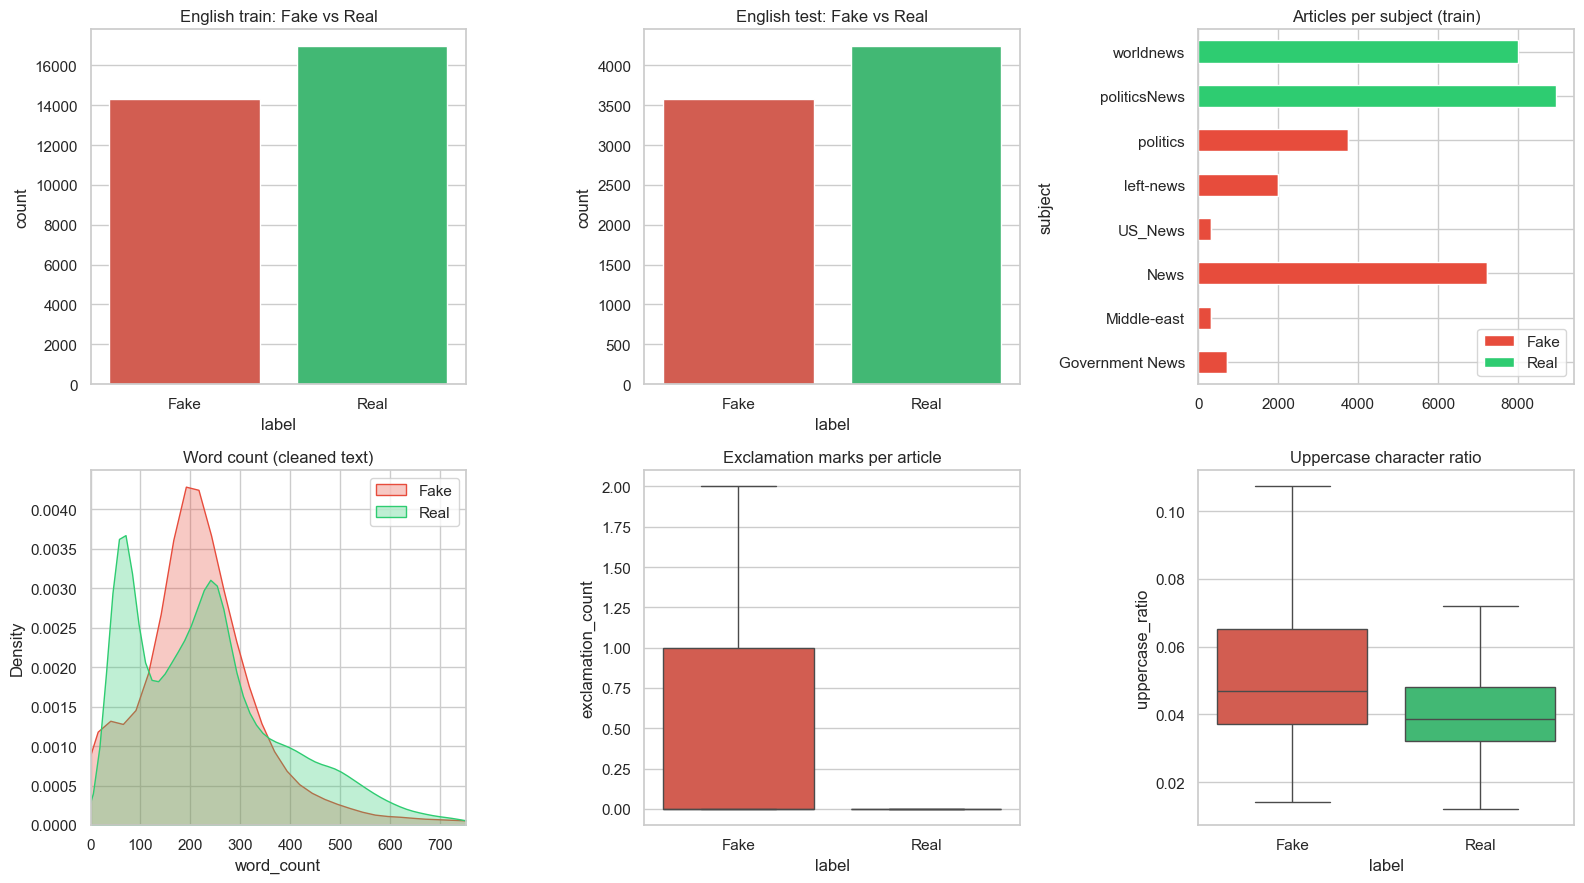


English label counts (train): {1: np.int64(16958), 0: np.int64(14323)}
English label counts (test) : {1: np.int64(4239), 0: np.int64(3580)}


In [25]:
# -----------------------------------------------------------
# ENGLISH EDA dashboard
# -----------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# (0,0) - class balance train
sns.countplot(x='label', data=train_df, ax=axes[0,0],
              palette=['#e74c3c','#2ecc71'])
axes[0,0].set_title('English train: Fake vs Real')
axes[0,0].set_xticklabels(['Fake','Real'])

# (0,1) - class balance test
sns.countplot(x='label', data=test_df, ax=axes[0,1],
              palette=['#e74c3c','#2ecc71'])
axes[0,1].set_title('English test: Fake vs Real')
axes[0,1].set_xticklabels(['Fake','Real'])

# (0,2) - subject distribution (where available)
subject_counts = train_df.groupby(['subject','label']).size().unstack(fill_value=0)
subject_counts.plot(kind='barh', stacked=True, ax=axes[0,2],
                    color=['#e74c3c','#2ecc71'])
axes[0,2].set_title('Articles per subject (train)')
axes[0,2].legend(['Fake','Real'])

# (1,0) - word count distribution
for lbl, name, col in [(0,'Fake','#e74c3c'),(1,'Real','#2ecc71')]:
    sns.kdeplot(train_df[train_df['label']==lbl]['word_count'],
                ax=axes[1,0], label=name, color=col, fill=True, alpha=0.3)
axes[1,0].set_xlim(0, train_df['word_count'].quantile(0.99))
axes[1,0].set_title('Word count (cleaned text)')
axes[1,0].legend()

# (1,1) - exclamation marks - good fake signal
sns.boxplot(x='label', y='exclamation_count', data=train_df, ax=axes[1,1],
            palette=['#e74c3c','#2ecc71'], showfliers=False)
axes[1,1].set_title('Exclamation marks per article')
axes[1,1].set_xticklabels(['Fake','Real'])

# (1,2) - uppercase ratio
sns.boxplot(x='label', y='uppercase_ratio', data=train_df, ax=axes[1,2],
            palette=['#e74c3c','#2ecc71'], showfliers=False)
axes[1,2].set_title('Uppercase character ratio')
axes[1,2].set_xticklabels(['Fake','Real'])

plt.tight_layout(); plt.show()
print('\nEnglish label counts (train):', dict(train_df['label'].value_counts()))
print('English label counts (test) :', dict(test_df['label'].value_counts()))


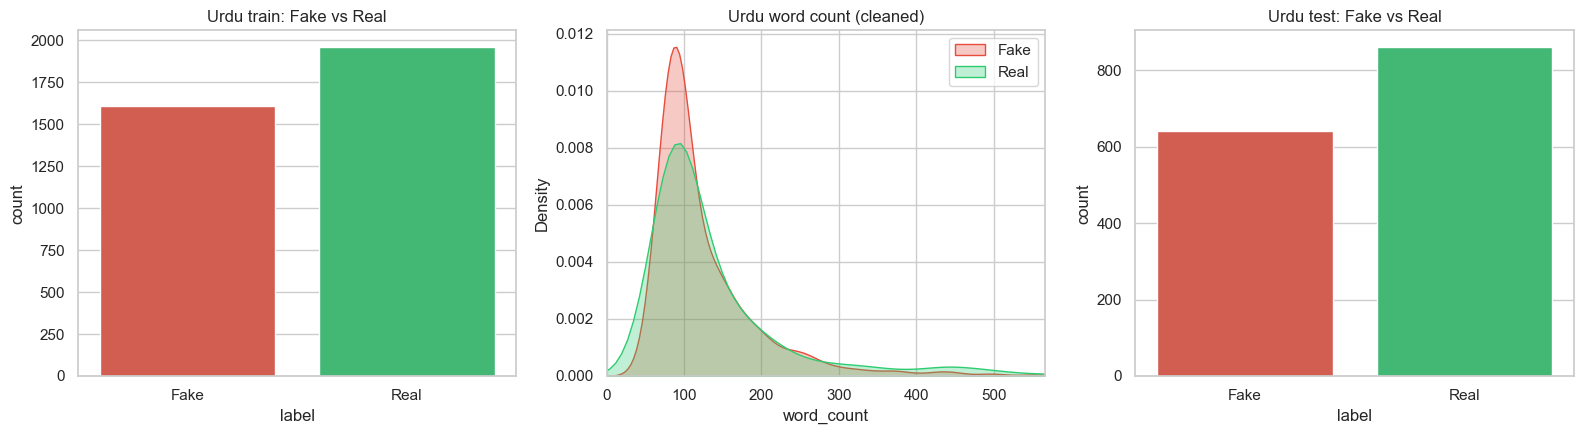

Urdu train counts: {1: np.int64(1961), 0: np.int64(1606)}
Urdu test  counts: {1: np.int64(861), 0: np.int64(641)}


In [26]:
# -----------------------------------------------------------
# URDU EDA dashboard
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.countplot(x='label', data=urdu_train_df, ax=axes[0],
              palette=['#e74c3c','#2ecc71'])
axes[0].set_title('Urdu train: Fake vs Real')
axes[0].set_xticklabels(['Fake','Real'])

for lbl, name, col in [(0,'Fake','#e74c3c'),(1,'Real','#2ecc71')]:
    sns.kdeplot(urdu_train_df[urdu_train_df['label']==lbl]['word_count'],
                ax=axes[1], label=name, color=col, fill=True, alpha=0.3)
axes[1].set_xlim(0, urdu_train_df['word_count'].quantile(0.99))
axes[1].set_title('Urdu word count (cleaned)')
axes[1].legend()

sns.countplot(x='label', data=urdu_test_df, ax=axes[2],
              palette=['#e74c3c','#2ecc71'])
axes[2].set_title('Urdu test: Fake vs Real')
axes[2].set_xticklabels(['Fake','Real'])

plt.tight_layout(); plt.show()
print('Urdu train counts:', dict(urdu_train_df['label'].value_counts()))
print('Urdu test  counts:', dict(urdu_test_df ['label'].value_counts()))


## 7. Word Clouds & Top Words
Which words dominate fake vs real articles in each language?

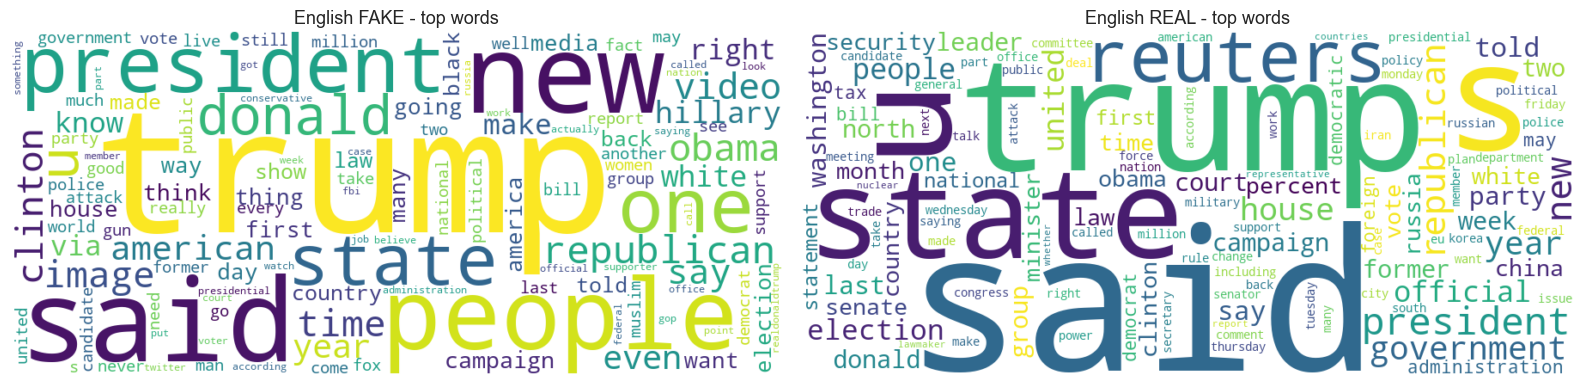

In [27]:
# Word clouds give a quick visual signal of class-discriminative vocabulary
def show_wordcloud(texts, title, ax, font_path=None, max_words=120):
    text_blob = ' '.join(texts)
    wc = WordCloud(
        width=900, height=400, background_color='white',
        max_words=max_words, collocations=False, font_path=font_path,
    ).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
show_wordcloud(train_df[train_df['label']==0]['content'].tolist(),
               'English FAKE - top words', axes[0])
show_wordcloud(train_df[train_df['label']==1]['content'].tolist(),
               'English REAL - top words', axes[1])
plt.tight_layout(); plt.show()


Urdu font: C:/Windows/Fonts/Arial.ttf


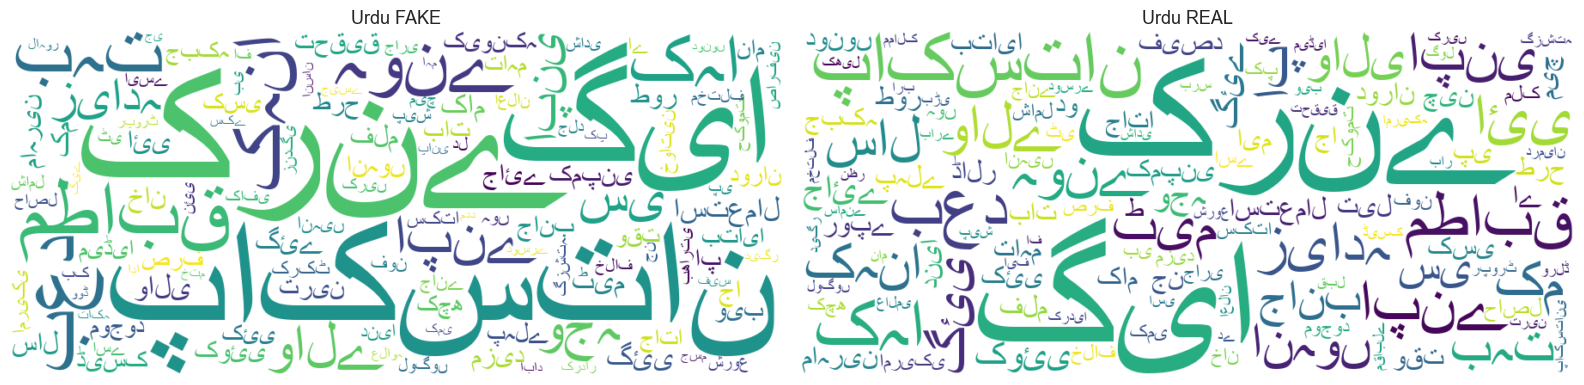

In [28]:
# Urdu word cloud 

URDU_FONT_CANDIDATES = [
    'C:/Windows/Fonts/NotoNastaliqUrdu-Regular.ttf',
    'C:/Windows/Fonts/Jameel Noori Nastaleeq.ttf',
    'C:/Windows/Fonts/Arial.ttf',
    '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
    '/Library/Fonts/Arial Unicode.ttf',
]
urdu_font = next((f for f in URDU_FONT_CANDIDATES if Path(f).exists()), None)
print('Urdu font:', urdu_font or 'none found - cloud may look broken')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
try:
    show_wordcloud(urdu_train_df[urdu_train_df['label']==0]['content'].tolist(),
                   'Urdu FAKE', axes[0], font_path=urdu_font)
    show_wordcloud(urdu_train_df[urdu_train_df['label']==1]['content'].tolist(),
                   'Urdu REAL', axes[1], font_path=urdu_font)
    plt.tight_layout(); plt.show()
except Exception as e:
    print('Urdu word cloud failed (probably font issue):', e)


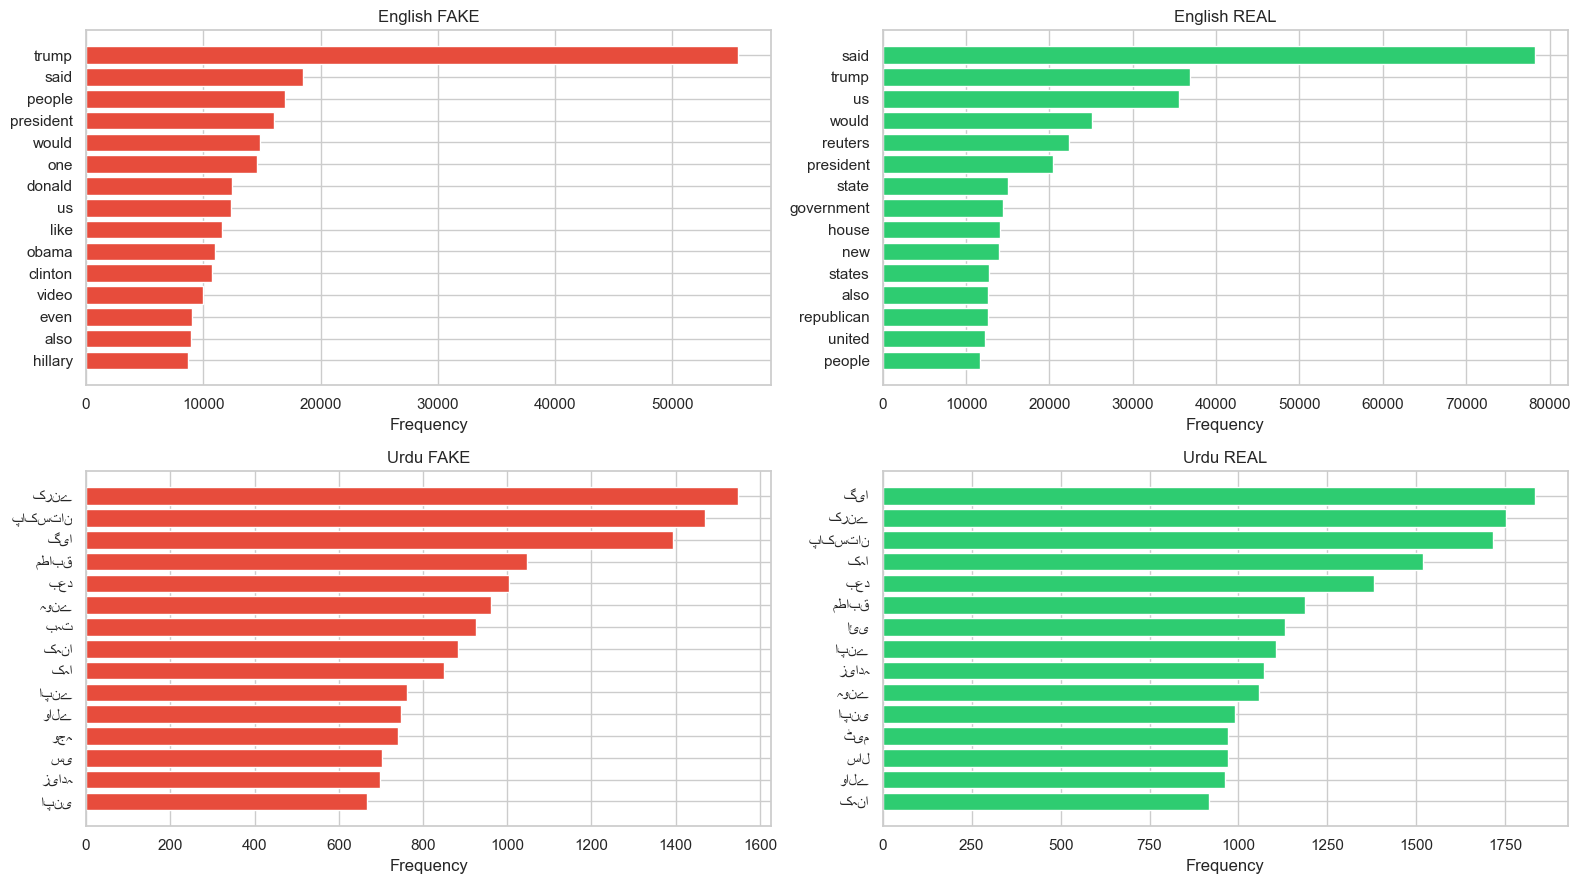

In [29]:
# Top-N word frequency bar chart for each class.
def top_words(series, n=20):
    c = Counter()
    for s in series:
        c.update(s.split())
    return c.most_common(n)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, (lang, fake_s, real_s) in zip(
    [axes[0,0], axes[0,1], axes[1,0], axes[1,1]],
    [
        ('English FAKE',  train_df[train_df['label']==0]['content'], None),
        ('English REAL',  train_df[train_df['label']==1]['content'], None),
        ('Urdu FAKE',     urdu_train_df[urdu_train_df['label']==0]['content'], None),
        ('Urdu REAL',     urdu_train_df[urdu_train_df['label']==1]['content'], None),
    ]):
    title, series, _ = lang, fake_s, real_s
    pairs = top_words(series, n=15)
    if not pairs:
        ax.set_visible(False); continue
    words, counts = zip(*pairs)
    ax.barh(list(words)[::-1], list(counts)[::-1],
            color='#e74c3c' if 'FAKE' in title else '#2ecc71')
    ax.set_title(title)
    ax.set_xlabel('Frequency')
plt.tight_layout(); plt.show()


## 8. TF-IDF Vectorization
English uses word-level 1-2 grams; Urdu uses character n-grams which capture morphology much better for under-resourced languages.

In [30]:
# -----------------------------------------------------------
# ENGLISH TF-IDF
# -----------------------------------------------------------
vectorizer = TfidfVectorizer(
    analyzer='word',
    stop_words='english',
    ngram_range=(1, 2),
    max_features=20000,
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
)
X_train = vectorizer.fit_transform(train_df['content'])
X_test  = vectorizer.transform(test_df ['content'])
y_train = train_df['label'].values
y_test  = test_df ['label'].values
print('English TF-IDF:')
print('  X_train:', X_train.shape)
print('  X_test :', X_test.shape)


English TF-IDF:
  X_train: (31281, 20000)
  X_test : (7819, 20000)


In [31]:
# -----------------------------------------------------------
# URDU TF-IDF (character n-grams)
# -----------------------------------------------------------
urdu_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=20000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)
urdu_X_train = urdu_vectorizer.fit_transform(urdu_train_df['content'])
urdu_X_test  = urdu_vectorizer.transform(urdu_test_df ['content'])
urdu_y_train = urdu_train_df['label'].values
urdu_y_test  = urdu_test_df ['label'].values
print('Urdu TF-IDF:')
print('  X_train:', urdu_X_train.shape)
print('  X_test :', urdu_X_test.shape)


Urdu TF-IDF:
  X_train: (3567, 20000)
  X_test : (1502, 20000)


## 9. Classical ML Models
Logistic Regression, Multinomial NB, Linear SVM, Random Forest, plus a soft-voting ensemble. SVC uses `probability=True` so it can be used by LIME and the trust score.

In [32]:
# -----------------------------------------------------------
# ENGLISH classifiers
# -----------------------------------------------------------
lr_model  = LogisticRegression(max_iter=2000, C=4.0, n_jobs=-1)
nb_model  = MultinomialNB(alpha=0.1)
svm_model = LinearSVC(C=1.0)
# Calibrate SVM so we get predict_proba (used by LIME and trust score).
svm_calibrated = CalibratedClassifierCV(LinearSVC(C=1.0), cv=3)
rf_model  = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    n_jobs=-1, random_state=RANDOM_STATE,
)

lr_model.fit(X_train, y_train)
nb_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
svm_calibrated.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

voting_model = VotingClassifier(
    estimators=[('lr', lr_model), ('nb', nb_model), ('svm', svm_calibrated)],
    voting='soft', n_jobs=-1,
)
voting_model.fit(X_train, y_train)
print('English models trained.')


English models trained.


In [33]:
# -----------------------------------------------------------
# URDU classifiers
# -----------------------------------------------------------
urdu_lr_model  = LogisticRegression(max_iter=2000, C=4.0, n_jobs=-1)
urdu_nb_model  = MultinomialNB(alpha=0.1)
urdu_svm_model = LinearSVC(C=1.0)
urdu_svm_calibrated = CalibratedClassifierCV(LinearSVC(C=1.0), cv=3)
urdu_rf_model  = RandomForestClassifier(
    n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE,
)

urdu_lr_model.fit(urdu_X_train, urdu_y_train)
urdu_nb_model.fit(urdu_X_train, urdu_y_train)
urdu_svm_model.fit(urdu_X_train, urdu_y_train)
urdu_svm_calibrated.fit(urdu_X_train, urdu_y_train)
urdu_rf_model.fit(urdu_X_train, urdu_y_train)

urdu_voting_model = VotingClassifier(
    estimators=[('lr', urdu_lr_model), ('nb', urdu_nb_model), ('svm', urdu_svm_calibrated)],
    voting='soft', n_jobs=-1,
)
urdu_voting_model.fit(urdu_X_train, urdu_y_train)
print('Urdu models trained.')


Urdu models trained.


## 10. Evaluation
We compute accuracy, precision, recall, F1, confusion matrices, ROC and PR curves.

In [34]:
def _probs(model, X):
    """Return positive-class probabilities or decision-function scores."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X)
        # Squash to (0,1) via logistic for ROC purposes only
        return 1.0 / (1.0 + np.exp(-scores))
    return model.predict(X).astype(float)

def evaluate_models(models, X_test, y_test, title, palette='Blues'):
    results = {}
    n = len(models)

    # confusion-matrix grid
    fig_cm, axes_cm = plt.subplots(1, n, figsize=(4.5*n, 4))
    if n == 1: axes_cm = [axes_cm]

    # ROC grid
    fig_roc, ax_roc = plt.subplots(1, 1, figsize=(7, 5))
    fig_pr , ax_pr  = plt.subplots(1, 1, figsize=(7, 5))

    for (name, model), ax_cm in zip(models.items(), axes_cm):
        preds = model.predict(X_test)
        probs = _probs(model, X_test)

        acc  = accuracy_score(y_test, preds)
        prec = precision_score(y_test, preds, zero_division=0)
        rec  = recall_score   (y_test, preds, zero_division=0)
        f1   = f1_score       (y_test, preds, zero_division=0)
        results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

        print(f'--- {name} ---')
        print(f'  Acc {acc:.4f}  Prec {prec:.4f}  Rec {rec:.4f}  F1 {f1:.4f}')
        print(classification_report(y_test, preds,
                                    target_names=['Fake','Real'], zero_division=0))

        cm = confusion_matrix(y_test, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap=palette,
                    xticklabels=['Fake','Real'], yticklabels=['Fake','Real'], ax=ax_cm)
        ax_cm.set_title(name)
        ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('Actual')

        # ROC
        fpr, tpr, _ = roc_curve(y_test, probs)
        roc_auc = auc(fpr, tpr)
        ax_roc.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')
        results[name]['ROC_AUC'] = roc_auc

        # PR
        p, r, _ = precision_recall_curve(y_test, probs)
        ap = average_precision_score(y_test, probs)
        ax_pr.plot(r, p, label=f'{name} (AP={ap:.3f})')
        results[name]['AvgPrecision'] = ap

    fig_cm.suptitle(f'{title} - Confusion matrices', y=1.02)
    fig_cm.tight_layout(); plt.show()

    ax_roc.plot([0,1],[0,1], 'k--', alpha=0.4)
    ax_roc.set_title(f'{title} - ROC curves')
    ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend(); fig_roc.tight_layout(); plt.show()

    ax_pr .set_title(f'{title} - Precision-Recall curves')
    ax_pr .set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
    ax_pr .legend(); fig_pr.tight_layout(); plt.show()
    return results


--- Logistic Regression ---
  Acc 0.9936  Prec 0.9922  Rec 0.9960  F1 0.9941
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      3580
        Real       0.99      1.00      0.99      4239

    accuracy                           0.99      7819
   macro avg       0.99      0.99      0.99      7819
weighted avg       0.99      0.99      0.99      7819

--- Naive Bayes ---
  Acc 0.9587  Prec 0.9662  Rec 0.9573  F1 0.9617
              precision    recall  f1-score   support

        Fake       0.95      0.96      0.96      3580
        Real       0.97      0.96      0.96      4239

    accuracy                           0.96      7819
   macro avg       0.96      0.96      0.96      7819
weighted avg       0.96      0.96      0.96      7819

--- Linear SVM ---
  Acc 0.9948  Prec 0.9950  Rec 0.9953  F1 0.9952
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      3580
        Real       1.00

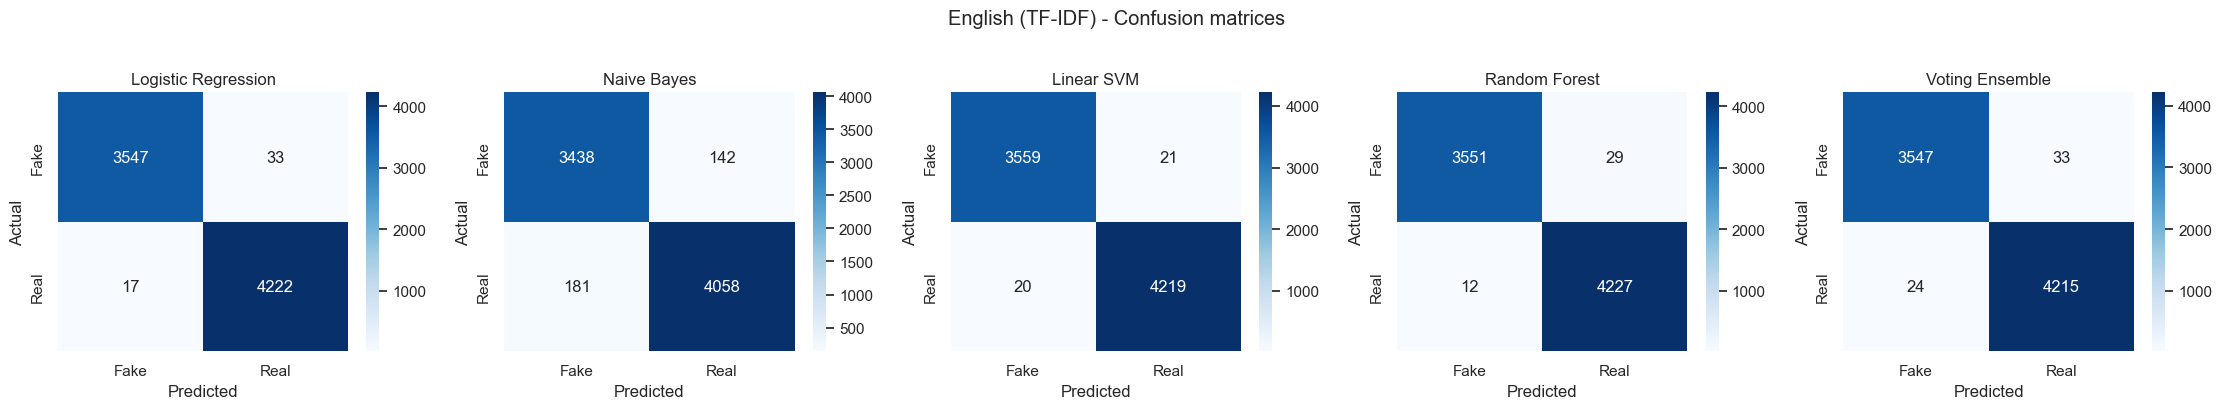

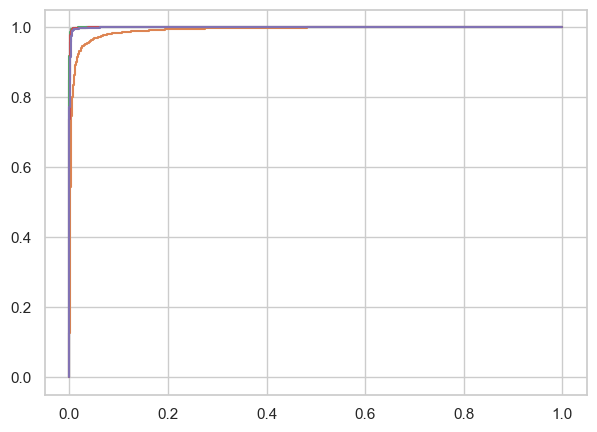

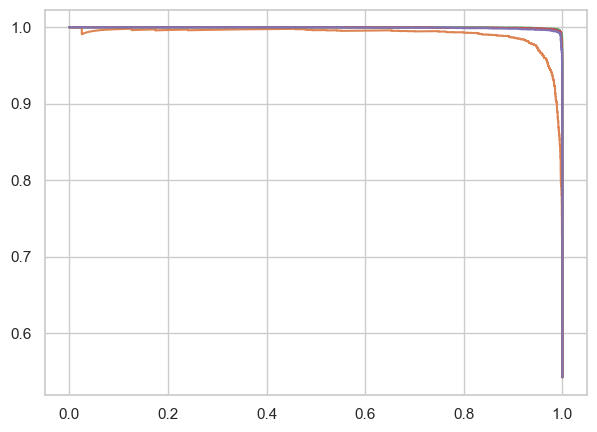

In [35]:
# -----------------------------------------------------------
# ENGLISH evaluation
# -----------------------------------------------------------
english_models = {
    'Logistic Regression': lr_model,
    'Naive Bayes'        : nb_model,
    'Linear SVM'         : svm_calibrated,
    'Random Forest'      : rf_model,
    'Voting Ensemble'    : voting_model,
}
english_results = evaluate_models(
    english_models, X_test, y_test,
    title='English (TF-IDF)', palette='Blues',
)


--- Logistic Regression ---
  Acc 0.8921  Prec 0.8994  Rec 0.9141  F1 0.9067
              precision    recall  f1-score   support

        Fake       0.88      0.86      0.87       641
        Real       0.90      0.91      0.91       861

    accuracy                           0.89      1502
   macro avg       0.89      0.89      0.89      1502
weighted avg       0.89      0.89      0.89      1502

--- Naive Bayes ---
  Acc 0.7730  Prec 0.8250  Rec 0.7666  F1 0.7947
              precision    recall  f1-score   support

        Fake       0.71      0.78      0.75       641
        Real       0.82      0.77      0.79       861

    accuracy                           0.77      1502
   macro avg       0.77      0.77      0.77      1502
weighted avg       0.78      0.77      0.77      1502

--- Linear SVM ---
  Acc 0.9041  Prec 0.9173  Rec 0.9152  F1 0.9163
              precision    recall  f1-score   support

        Fake       0.89      0.89      0.89       641
        Real       0.92

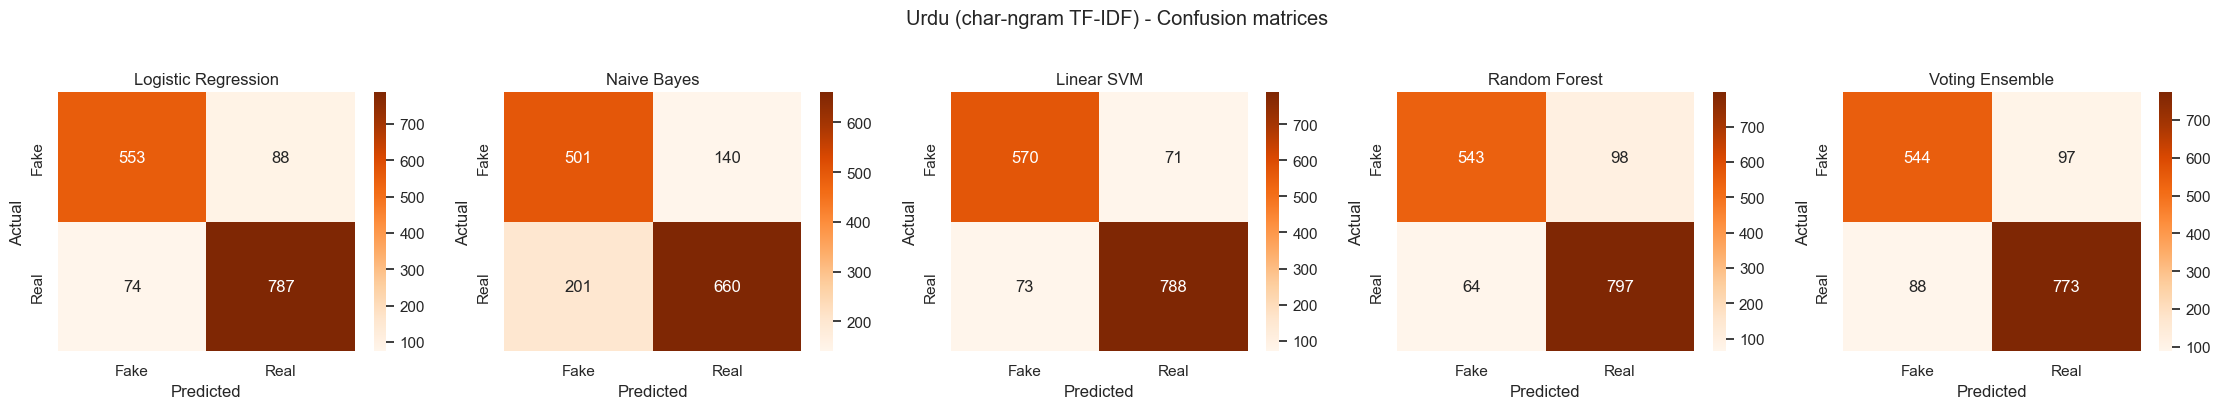

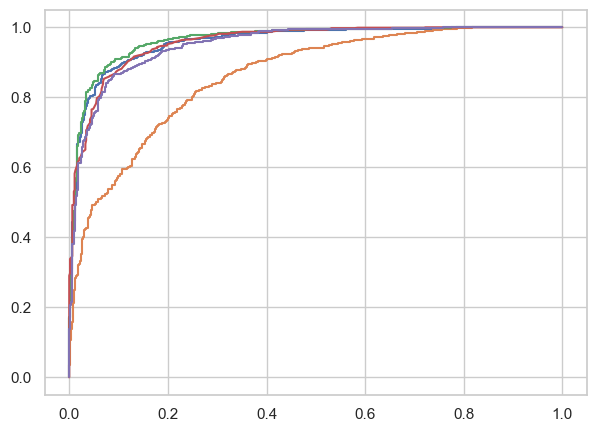

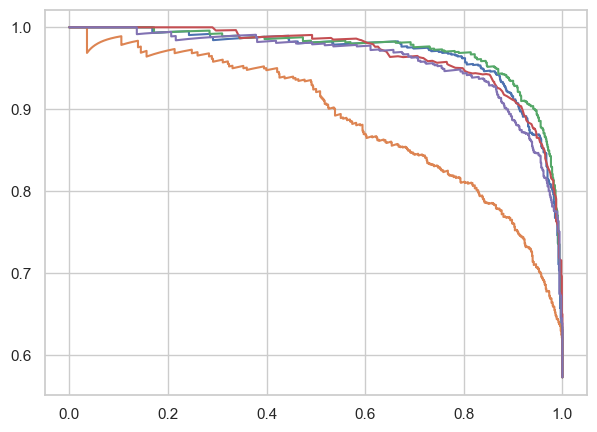

In [36]:
# -----------------------------------------------------------
# URDU evaluation
# -----------------------------------------------------------
urdu_models = {
    'Logistic Regression': urdu_lr_model,
    'Naive Bayes'        : urdu_nb_model,
    'Linear SVM'         : urdu_svm_calibrated,
    'Random Forest'      : urdu_rf_model,
    'Voting Ensemble'    : urdu_voting_model,
}
urdu_results = evaluate_models(
    urdu_models, urdu_X_test, urdu_y_test,
    title='Urdu (char-ngram TF-IDF)', palette='Oranges',
)


## 11. Comparative Bar Charts

=== English metrics ===
                     Accuracy  Precision  Recall      F1  ROC_AUC  \
Logistic Regression    0.9936     0.9922  0.9960  0.9941   0.9995   
Naive Bayes            0.9587     0.9662  0.9573  0.9617   0.9912   
Linear SVM             0.9948     0.9950  0.9953  0.9952   0.9998   
Random Forest          0.9948     0.9932  0.9972  0.9952   0.9996   
Voting Ensemble        0.9927     0.9922  0.9943  0.9933   0.9992   

                     AvgPrecision  
Logistic Regression        0.9996  
Naive Bayes                0.9913  
Linear SVM                 0.9998  
Random Forest              0.9996  
Voting Ensemble            0.9993  

=== Urdu metrics ===
                     Accuracy  Precision  Recall      F1  ROC_AUC  \
Logistic Regression    0.8921     0.8994  0.9141  0.9067   0.9593   
Naive Bayes            0.7730     0.8250  0.7666  0.7947   0.8621   
Linear SVM             0.9041     0.9173  0.9152  0.9163   0.9657   
Random Forest          0.8921     0.8905  0.925

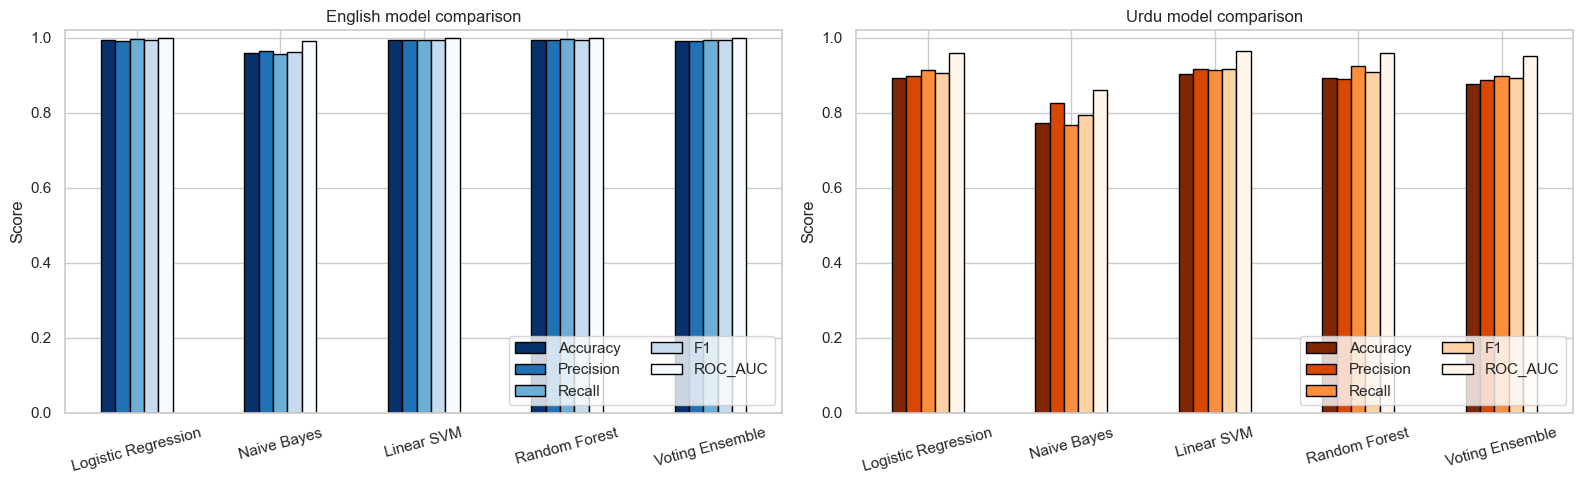

In [37]:
english_results_df = pd.DataFrame(english_results).T
urdu_results_df    = pd.DataFrame(urdu_results).T

print('=== English metrics ===')
print(english_results_df.round(4))
print()
print('=== Urdu metrics ===')
print(urdu_results_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
english_results_df[['Accuracy','Precision','Recall','F1','ROC_AUC']].plot(
    kind='bar', ax=axes[0], ylim=(0, 1.02), rot=15,
    colormap='Blues_r', edgecolor='black')
axes[0].set_title('English model comparison')
axes[0].set_ylabel('Score'); axes[0].legend(loc='lower right', ncol=2)

urdu_results_df[['Accuracy','Precision','Recall','F1','ROC_AUC']].plot(
    kind='bar', ax=axes[1], ylim=(0, 1.02), rot=15,
    colormap='Oranges_r', edgecolor='black')
axes[1].set_title('Urdu model comparison')
axes[1].set_ylabel('Score'); axes[1].legend(loc='lower right', ncol=2)
plt.tight_layout(); plt.show()


## 12. Cross-Validated Stability
5-fold stratified CV on the strongest baselines tells us whether the test-set numbers above are stable or just lucky.

=== English - 5-fold CV F1 ===
          LR      NB  LinSVC
mean  0.9939  0.9643  0.9963
std   0.0018  0.0008  0.0008
min   0.9919  0.9634  0.9956
max   0.9966  0.9652  0.9975


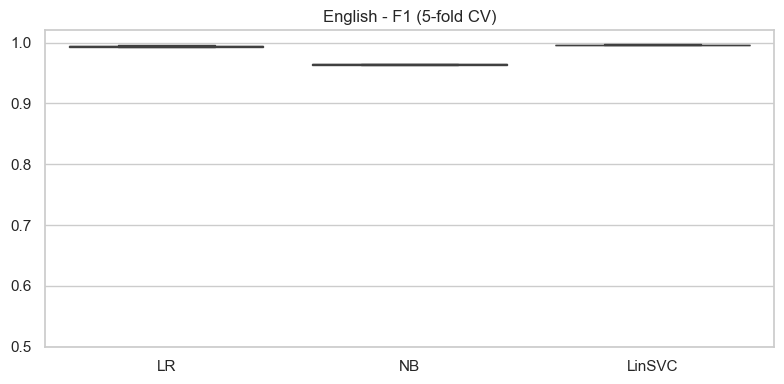

=== Urdu - 5-fold CV F1 ===
          LR      NB  LinSVC
mean  0.8971  0.7783  0.9198
std   0.0116  0.0153  0.0141
min   0.8789  0.7599  0.9105
max   0.9095  0.8016  0.9446


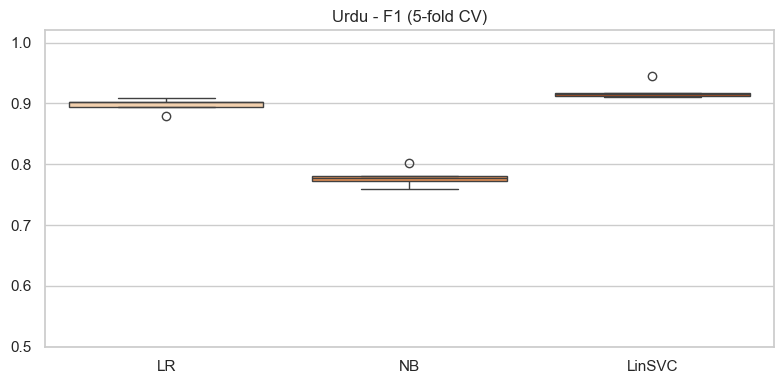

In [38]:
def cv_box(models, X, y, title, color):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = {n: cross_val_score(m, X, y, cv=cv, scoring='f1', n_jobs=-1)
              for n, m in models.items()}
    df = pd.DataFrame(scores)
    print(f'=== {title} - 5-fold CV F1 ===')
    print(df.describe().round(4).loc[['mean','std','min','max']])
    fig, ax = plt.subplots(figsize=(8,4))
    sns.boxplot(data=df, ax=ax, palette=color)
    ax.set_title(f'{title} - F1 (5-fold CV)')
    ax.set_ylim(0.5, 1.02)
    plt.tight_layout(); plt.show()
    return df

_ = cv_box(
    {'LR': LogisticRegression(max_iter=2000, C=4.0, n_jobs=-1),
     'NB': MultinomialNB(alpha=0.1),
     'LinSVC': LinearSVC(C=1.0)},
    X_train, y_train, 'English', 'Blues',
)
_ = cv_box(
    {'LR': LogisticRegression(max_iter=2000, C=4.0, n_jobs=-1),
     'NB': MultinomialNB(alpha=0.1),
     'LinSVC': LinearSVC(C=1.0)},
    urdu_X_train, urdu_y_train, 'Urdu', 'Oranges',
)


## 13. Top TF-IDF Features per Class
Most-predictive n-grams for fake vs real, as judged by the logistic-regression coefficients.

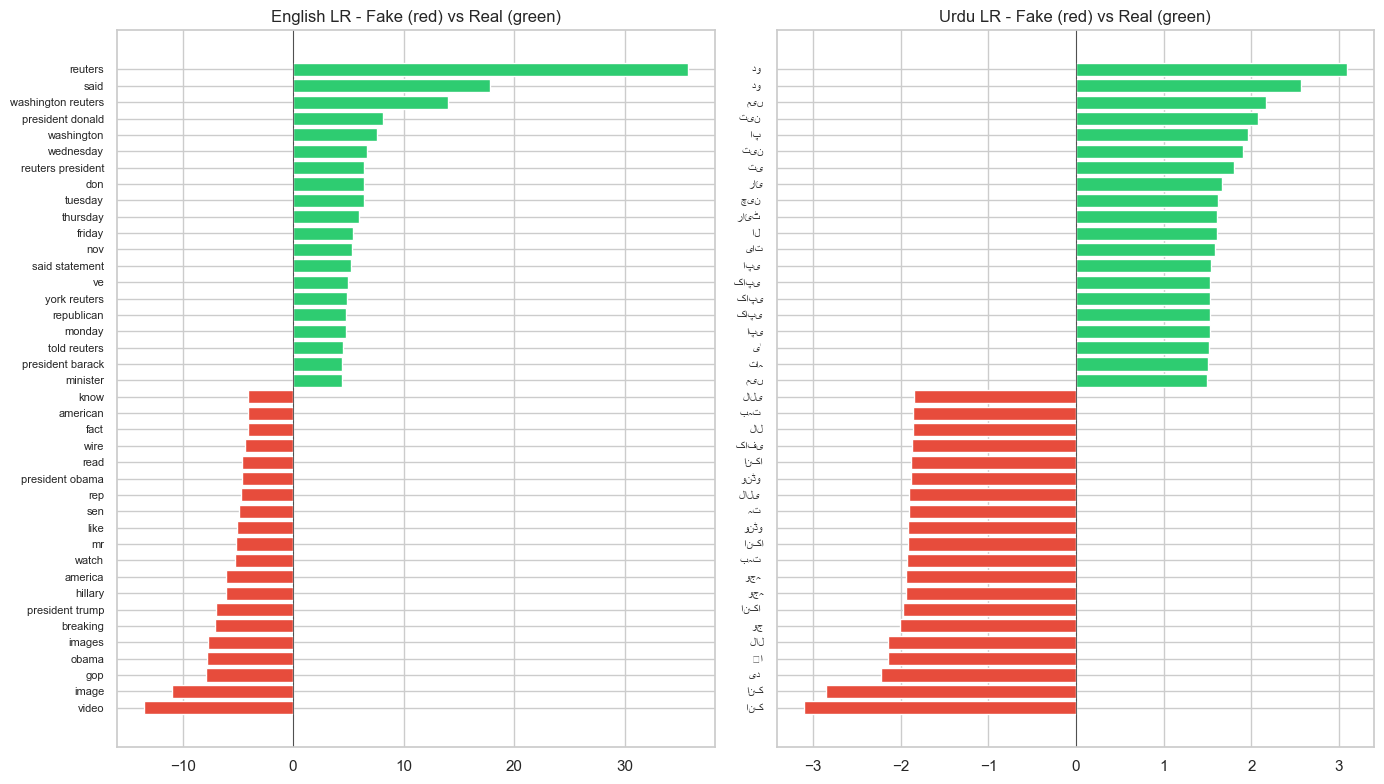

In [39]:
def plot_top_features(model, vec, ax, title, n=20):
    if not hasattr(model, 'coef_'):
        ax.set_visible(False); return
    coefs = model.coef_.ravel()
    names = np.array(vec.get_feature_names_out())
    top_pos = np.argsort(coefs)[-n:]
    top_neg = np.argsort(coefs)[:n]
    feats = np.concatenate([names[top_neg], names[top_pos]])
    vals  = np.concatenate([coefs[top_neg], coefs[top_pos]])
    colors = ['#e74c3c']*n + ['#2ecc71']*n
    ax.barh(range(2*n), vals, color=colors)
    ax.set_yticks(range(2*n))
    ax.set_yticklabels(feats, fontsize=8)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
plot_top_features(lr_model,       vectorizer,       axes[0], 'English LR - Fake (red) vs Real (green)')
plot_top_features(urdu_lr_model,  urdu_vectorizer,  axes[1], 'Urdu LR - Fake (red) vs Real (green)')
plt.tight_layout(); plt.show()


## 14. Transformer Models



In [40]:
if HAS_TRANSFORMERS:
    try:
        import torch
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
        print('Transformer device:', device)

        N_TRAIN_EN = min(500, len(english_df))
        N_EVAL_EN  = min(200,  len(english_df))

        english_model_name = 'distilbert-base-uncased'
        english_tokenizer = AutoTokenizer.from_pretrained(english_model_name)

        en_train_df = english_df[['text', 'label']].rename(columns={'label': 'labels'}).iloc[:N_TRAIN_EN].copy()
        en_test_df = english_df[['text', 'label']].rename(columns={'label': 'labels'}).iloc[-N_EVAL_EN:].copy()

        def tok_en(ex):
            return english_tokenizer(
                ex['text'],
                truncation=True,
                padding='max_length',
                max_length=128,
            )

        en_train_ds = Dataset.from_pandas(en_train_df)
        en_test_ds = Dataset.from_pandas(en_test_df)
        en_train_ds = en_train_ds.map(tok_en, batched=True, remove_columns=['text'])
        en_test_ds = en_test_ds.map(tok_en, batched=True, remove_columns=['text'])

        english_transformer_model = AutoModelForSequenceClassification.from_pretrained(
            english_model_name, num_labels=2
        )
        english_transformer_model.to(device)
        print('English tokenizer + model ready.')
    except Exception as e:
        print('English transformer setup failed:', e)
        english_transformer_model = None
        en_train_ds = None
        en_test_ds = None
        en_trainer = None
else:
    print('Skipping: HAS_TRANSFORMERS is False.')


Transformer device: cpu


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1966.12it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


English tokenizer + model ready.


In [41]:
if HAS_TRANSFORMERS and english_transformer_model is not None and en_train_ds is not None and en_test_ds is not None:
    try:
        english_training_args = TrainingArguments(
            output_dir='./english_results',
            num_train_epochs=1,
            per_device_train_batch_size=4 if str(device) == 'cpu' else 8,
            per_device_eval_batch_size=4 if str(device) == 'cpu' else 8,
            learning_rate=2e-5,
            weight_decay=0.01,
            logging_steps=10,
            save_strategy='no',
            report_to=[],
            use_cpu=str(device) == 'cpu',
            optim='adamw_torch',
            bf16=False,
        )

        en_trainer = Trainer(
            model=english_transformer_model,
            args=english_training_args,
            train_dataset=en_train_ds,
            eval_dataset=en_test_ds,
        )
        en_trainer.train()
    except Exception as e:
        print('English transformer training failed:', e)
        en_trainer = None
else:
    print('Skipping: transformer training is not ready.')


Step,Training Loss
10,0.662684
20,0.588552
30,0.457721
40,0.285992
50,0.160807
60,0.080039
70,0.043884
80,0.027143
90,0.021635
100,0.018971


In [42]:
if HAS_TRANSFORMERS and en_trainer is not None:
    try:
        en_pred = en_trainer.predict(en_test_ds)
        en_preds = np.argmax(en_pred.predictions, axis=1)
        en_true = np.array(en_test_ds['labels'])
        print('English transformer:')
        print(classification_report(en_true, en_preds,
                                    target_names=['Fake','Real'], zero_division=0))
        transformer_en_acc = accuracy_score(en_true, en_preds)
        transformer_en_f1 = f1_score(en_true, en_preds)
    except Exception as e:
        print('English transformer evaluation failed:', e)
        transformer_en_acc = None
        transformer_en_f1 = None
else:
    transformer_en_acc = transformer_en_f1 = None


English transformer:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00        86
        Real       1.00      1.00      1.00       114

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [43]:
if HAS_TRANSFORMERS:
    try:
        import torch
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
        print('Transformer device:', device)

        N_TRAIN_UR = min(500, len(urdu_train_df))
        N_EVAL_UR  = min(200,  len(urdu_test_df))

        urdu_model_name = 'bert-base-multilingual-cased'
        urdu_tokenizer = AutoTokenizer.from_pretrained(urdu_model_name)

        urdu_train_df = urdu_train_df[['text', 'label']].rename(columns={'label': 'labels'}).iloc[:N_TRAIN_UR].copy()
        urdu_test_df = urdu_test_df[['text', 'label']].rename(columns={'label': 'labels'}).iloc[:N_EVAL_UR].copy()

        def tok_ur(ex):
            return urdu_tokenizer(
                ex['text'],
                truncation=True,
                padding='max_length',
                max_length=128,
            )

        urdu_train_ds = Dataset.from_pandas(urdu_train_df)
        urdu_test_ds = Dataset.from_pandas(urdu_test_df)
        urdu_train_ds = urdu_train_ds.map(tok_ur, batched=True, remove_columns=['text'])
        urdu_test_ds = urdu_test_ds.map(tok_ur, batched=True, remove_columns=['text'])

        urdu_transformer_model = AutoModelForSequenceClassification.from_pretrained(
            urdu_model_name, num_labels=2
        )
        urdu_transformer_model.to(device)
        print('Urdu tokenizer + model ready.')
    except Exception as e:
        print('Urdu transformer setup failed:', e)
        urdu_transformer_model = None
        urdu_train_ds = None
        urdu_test_ds = None
        ur_trainer = None
else:
    print('Skipping: HAS_TRANSFORMERS is False.')


Transformer device: cpu


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2924.69it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from t

Urdu tokenizer + model ready.


In [44]:
if HAS_TRANSFORMERS and urdu_transformer_model is not None and urdu_train_ds is not None and urdu_test_ds is not None:
    print('Urdu transformer training skipped to avoid kernel crashes on this machine.')
    transformer_ur_acc = None
    transformer_ur_f1 = None
else:
    transformer_ur_acc = transformer_ur_f1 = None


Urdu transformer training skipped to avoid kernel crashes on this machine.


## 16. Classical vs Transformer - final comparison

      Lang                    Model  Accuracy      F1
0  English   Random Forest (TF-IDF)    0.9948  0.9952
1     Urdu      Linear SVM (TF-IDF)    0.9041  0.9163
2  English  DistilBERT (fine-tuned)    1.0000  1.0000


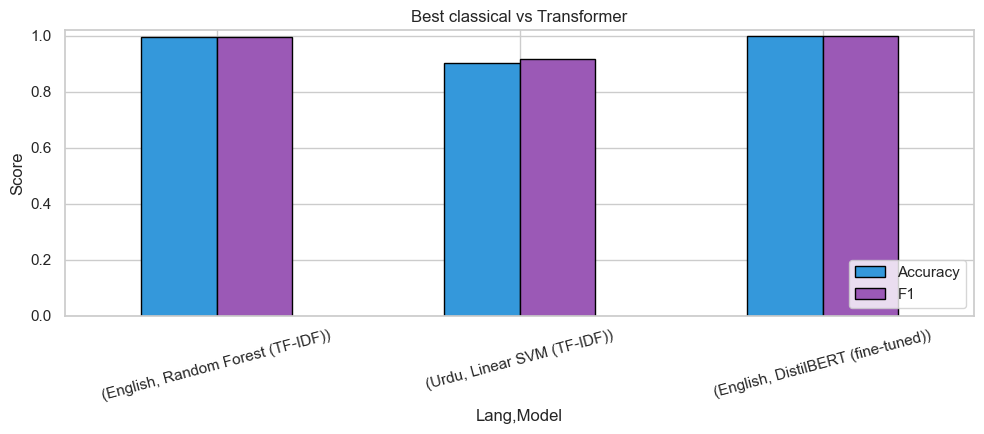

In [45]:
best_en_classical_name = max(english_results, key=lambda k: english_results[k]['F1'])
best_ur_classical_name = max(urdu_results,    key=lambda k: urdu_results   [k]['F1'])

rows = []
rows.append({'Lang':'English', 'Model':best_en_classical_name + ' (TF-IDF)',
             'Accuracy':english_results[best_en_classical_name]['Accuracy'],
             'F1':english_results[best_en_classical_name]['F1']})
rows.append({'Lang':'Urdu', 'Model':best_ur_classical_name + ' (TF-IDF)',
             'Accuracy':urdu_results   [best_ur_classical_name]['Accuracy'],
             'F1':urdu_results   [best_ur_classical_name]['F1']})
if transformer_en_acc is not None:
    rows.append({'Lang':'English', 'Model':'DistilBERT (fine-tuned)',
                 'Accuracy':transformer_en_acc, 'F1':transformer_en_f1})
if transformer_ur_acc is not None:
    rows.append({'Lang':'Urdu', 'Model':'mBERT (fine-tuned)',
                 'Accuracy':transformer_ur_acc, 'F1':transformer_ur_f1})
summary = pd.DataFrame(rows)
print(summary.round(4))

fig, ax = plt.subplots(figsize=(10, 4.5))
summary_pivot = summary.set_index(['Lang','Model'])[['Accuracy','F1']]
summary_pivot.plot(kind='bar', ax=ax, ylim=(0, 1.02), rot=15,
                   color=['#3498db','#9b59b6'], edgecolor='black')
ax.set_title('Best classical vs Transformer')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()


## 17. Inference Utilities
Trust score, gibberish guard, and the agent-style runner.

In [46]:
def get_trust_score(probability):
    """probability = P(real). Returns (0-100 score, human label)."""
    score = int(round(float(probability) * 100))
    if   score >= 80: category = 'Highly Trustworthy'
    elif score >= 60: category = 'Mostly Reliable'
    elif score >= 50: category = 'Uncertain - Likely Real'
    elif score >= 35: category = 'Suspicious'
    else            : category = 'Potentially Misleading'
    return score, category


In [47]:
def is_gibberish(text, cleaned_text, threshold=0.5):
    """Return (gibberish?, reason) for Urdu input."""
    words = cleaned_text.split()
    if len(words) < 3:
        return True, 'Text too short after cleaning'
    for word in words:
        if len(word) >= 3 and len(set(word)) == 1:
            return True, 'Repeated-character pattern'
    avg_len = sum(len(w) for w in words) / len(words)
    if avg_len < 2.5:
        return True, 'Average word too short'
    urdu_chars  = sum(1 for c in text if '\u0600' <= c <= '\u06FF')
    total_chars = len([c for c in text if not c.isspace()])
    if total_chars > 0 and urdu_chars / total_chars < threshold:
        return True, 'Not enough Urdu script content'
    return False, ''


In [48]:
# -----------------------------------------------------------
# AGENTIC AI SYSTEM
# -----------------------------------------------------------
class LanguageAgent:
    def detect_language(self, text):
        urdu_chars = sum(1 for c in text if '\u0600' <= c <= '\u06FF')
        return 'urdu' if urdu_chars > 10 else 'english'

class CleaningAgent:
    def clean(self, text, language):
        return clean_urdu_text(text) if language == 'urdu' else clean_english_text(text)

class PredictionAgent:
    def predict(self, text, language):
        if language == 'urdu':
            vec = urdu_vectorizer.transform([text])
            pred = urdu_voting_model.predict(vec)[0]
            prob = urdu_voting_model.predict_proba(vec)[0][1]
        else:
            vec = vectorizer.transform([text])
            pred = voting_model.predict(vec)[0]
            prob = voting_model.predict_proba(vec)[0][1]
        return pred, prob

class TrustAgent:
    def analyze(self, probability):
        return get_trust_score(probability)

class FakeNewsAgent:
    def __init__(self):
        self.language_agent  = LanguageAgent()
        self.cleaning_agent  = CleaningAgent()
        self.prediction_agent= PredictionAgent()
        self.trust_agent     = TrustAgent()
    def process_news(self, news):
        language = self.language_agent.detect_language(news)
        cleaned  = self.cleaning_agent.clean(news, language)
        if language == 'urdu':
            gib, reason = is_gibberish(news, cleaned)
            if gib:
                return {'Language':language, 'Prediction':'Rejected',
                        'Trust Score':0, 'Category':'Invalid Urdu input',
                        'Reason':reason}
        pred, prob = self.prediction_agent.predict(cleaned, language)
        score, cat = self.trust_agent.analyze(prob)
        return {
            'Language'   : language,
            'Prediction' : 'Real' if pred == 1 else 'Fake',
            'Confidence' : round(float(prob), 4),
            'Trust Score': score,
            'Category'   : cat,
        }

agent = FakeNewsAgent()
print('Agent ready. Try: agent.process_news("Some news text here")')


Agent ready. Try: agent.process_news("Some news text here")


## 18. LIME Explainability
Each function uses the **correct** vectorizer / model for its language

In [49]:
def explain_english(news_text, n_features=10):
    if not HAS_LIME:
        print('LIME not installed.'); return
    explainer = LimeTextExplainer(class_names=['Fake','Real'])

    def predict_proba(texts):
        cleaned = [clean_english_text(t) for t in texts]
        vecs    = vectorizer.transform(cleaned)
        return voting_model.predict_proba(vecs)

    exp = explainer.explain_instance(news_text, predict_proba, num_features=n_features)
    try:
        exp.show_in_notebook(text=True)
    except Exception:
        for word, weight in exp.as_list():
            print(f'  {word:<25s} {weight:+.4f}')
    return exp

def explain_urdu(news_text, n_features=10):
    if not HAS_LIME:
        print('LIME not installed.'); return
    explainer = LimeTextExplainer(class_names=['Fake','Real'])

    def predict_proba(texts):
        cleaned = [clean_urdu_text(t) for t in texts]
        vecs    = urdu_vectorizer.transform(cleaned)
        return urdu_voting_model.predict_proba(vecs)

    exp = explainer.explain_instance(news_text, predict_proba, num_features=n_features)
    try:
        exp.show_in_notebook(text=True)
    except Exception:
        for word, weight in exp.as_list():
            print(f'  {word:<25s} {weight:+.4f}')
    return exp


## 19. Persist Models

In [50]:
def save_pickle(obj, path):
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print('Saved:', path)

# English
save_pickle(lr_model,           'models/en_lr_model.pkl')
save_pickle(nb_model,           'models/en_nb_model.pkl')
save_pickle(svm_model,          'models/en_svm_model.pkl')
save_pickle(svm_calibrated,     'models/en_svm_calibrated.pkl')
save_pickle(rf_model,           'models/en_rf_model.pkl')
save_pickle(voting_model,       'models/en_voting_model.pkl')
save_pickle(vectorizer,         'models/en_tfidf_vectorizer.pkl')

# Urdu 
save_pickle(urdu_lr_model,      'models/ur_lr_model.pkl')
save_pickle(urdu_nb_model,      'models/ur_nb_model.pkl')
save_pickle(urdu_svm_model,     'models/ur_svm_model.pkl')
save_pickle(urdu_svm_calibrated,'models/ur_svm_calibrated.pkl')
save_pickle(urdu_rf_model,      'models/ur_rf_model.pkl')
save_pickle(urdu_voting_model,  'models/ur_voting_model.pkl')
save_pickle(urdu_vectorizer,    'models/ur_tfidf_vectorizer.pkl')

if HAS_TRANSFORMERS:
    try:
        english_transformer_model.save_pretrained('models/english_transformer_model')
        english_tokenizer        .save_pretrained('models/english_transformer_model')
        urdu_transformer_model   .save_pretrained('models/urdu_transformer_model')
        urdu_tokenizer           .save_pretrained('models/urdu_transformer_model')
        print('Transformer checkpoints saved.')
    except Exception as e:
        print('Saving transformers failed:', e)


Saved: models/en_lr_model.pkl
Saved: models/en_nb_model.pkl
Saved: models/en_svm_model.pkl
Saved: models/en_svm_calibrated.pkl
Saved: models/en_rf_model.pkl
Saved: models/en_voting_model.pkl
Saved: models/en_tfidf_vectorizer.pkl
Saved: models/ur_lr_model.pkl
Saved: models/ur_nb_model.pkl
Saved: models/ur_svm_model.pkl
Saved: models/ur_svm_calibrated.pkl
Saved: models/ur_rf_model.pkl
Saved: models/ur_voting_model.pkl
Saved: models/ur_tfidf_vectorizer.pkl


Writing model shards: 100%|██████████| 1/1 [00:15<00:00, 15.09s/it]

Transformer checkpoints saved.


In [51]:
def download_model_file(path):
    p = Path(path)
    if not p.exists():
        print(f'File not found: {p}')
        return

    try:
        from google.colab import files as colab_files
        colab_files.download(str(p))
    except Exception:
        print(f'Local download fallback: {p.resolve()}')

for model_file in [
    'models/en_voting_model.pkl',
    'models/en_tfidf_vectorizer.pkl',
    'models/ur_voting_model.pkl',
    'models/ur_tfidf_vectorizer.pkl',
]:
    download_model_file(model_file)


Local download fallback: C:\MY SEMESTER PROJECTS\Fake News Detection\models\en_voting_model.pkl
Local download fallback: C:\MY SEMESTER PROJECTS\Fake News Detection\models\en_tfidf_vectorizer.pkl
Local download fallback: C:\MY SEMESTER PROJECTS\Fake News Detection\models\ur_voting_model.pkl
Local download fallback: C:\MY SEMESTER PROJECTS\Fake News Detection\models\ur_tfidf_vectorizer.pkl


## 20. Interactive Runner
Enter a sentence and the agent will detect the language, classify it, and report a trust score.

In [53]:
def run_english_model(show_explanation=False):
    news = input('Enter English news text: ').strip()
    cleaned = clean_english_text(news)
    vec  = vectorizer.transform([cleaned])             
    prob = voting_model.predict_proba(vec)[0][1]
    pred = voting_model.predict(vec)[0]
    score, cat = get_trust_score(prob)
    print()
    print(f'Prediction      : {"Real" if pred==1 else "Fake"}')
    print(f'P(real)         : {prob:.4f}')
    print(f'Trustworthiness : {score}/100')
    print(f'Category        : {cat}')
    if HAS_LIME and show_explanation:
        explain_english(news)

def run_urdu_model(show_explanation=False):
    news = input('Enter Urdu news text: ').strip()
    cleaned = clean_urdu_text(news)
    gib, reason = is_gibberish(news, cleaned)
    if gib:
        print('Input rejected -', reason); return
    vec  = urdu_vectorizer.transform([cleaned])        
    prob = urdu_voting_model.predict_proba(vec)[0][1]
    pred = urdu_voting_model.predict(vec)[0]
    score, cat = get_trust_score(prob)
    print()
    print(f'Prediction      : {"Real" if pred==1 else "Fake"}')
    print(f'P(real)         : {prob:.4f}')
    print(f'Trustworthiness : {score}/100')
    print(f'Category        : {cat}')
    print('\n--- per-model predictions ---')
    for name, m in urdu_models.items():
        p = m.predict(vec)[0]
        print(f'  {name:<22s}: {"Real" if p==1 else "Fake"}')
    if HAS_LIME and show_explanation:
        explain_urdu(news)


In [54]:
print('===== Fake News Detection System =====')
print('1 -> English News')
print('2 -> Urdu News')
print('3 -> Auto-detect via agent')
print('Tip: the app runs faster if you skip the explanation step.')
choice = input('Select (1/2/3): ').strip()
if choice == '1':
    run_english_model(show_explanation=False)
elif choice == '2':
    run_urdu_model(show_explanation=False)
elif choice == '3':
    txt = input('Enter news text: ').strip()
    result = agent.process_news(txt)
    print('\n===== Agent Analysis =====')
    for k, v in result.items():
        print(f'{k:<12s}: {v}')
else:
    print('Invalid selection.')


===== Fake News Detection System =====
1 -> English News
2 -> Urdu News
3 -> Auto-detect via agent
Tip: the app runs faster if you skip the explanation step.

Prediction      : Real
P(real)         : 0.8577
Trustworthiness : 86/100
Category        : Highly Trustworthy
